### Imports

In [1]:
import numpy as np
import random
from collections import defaultdict
import matplotlib.pyplot as plt

from simhash import Simhash

from datasketch import MinHash

In [103]:
myHasher = MinHash(n_hash_tables=10)
# myHasher.fit_predict(df, 'name')

In [95]:
def generate_bitvector_pair(length, hamming_distance):
	vec1 = np.random.randint(0, 2, length, dtype=np.uint8)
	vec2 = vec1.copy()
	# print(length, hamming_distance)
	flip_positions = random.sample(range(length), hamming_distance)
	for pos in flip_positions:
		vec2[pos] = 1 - vec2[pos]  # Flip bit
	return vec1, vec2


def bitvector_to_string(bitvector):
    """Convert bitvector to string for Simhash input"""
    return ''.join(map(str, bitvector))

def compute_simhash_collision_rate(length, num_samples, similarity_arr):
	arr_counts = np.zeros(len(similarity_arr), dtype=np.float32)
	idx = 0
	print(similarity_arr)
	for i in similarity_arr:
		hamming_distance = int(length * (1 - i))
		# print(f"Hamming distance: {hamming_distance}")
		# print(f"Index: {idx}")
		for j in range(num_samples):
			# Generate a pair of bitvectors with the specified Hamming distance
			vec1, vec2 = generate_bitvector_pair(length, hamming_distance)
			# Convert to string for Simhash
			str_vec1 = bitvector_to_string(vec1)
			str_vec2 = bitvector_to_string(vec2)
			
			hash1 = Simhash(str_vec1)
			hash2 = Simhash(str_vec2)

			if(hash1 == hash2):
				arr_counts[idx] += 1
	
		idx += 1
	
	# Print the results
	arr_counts = arr_counts / num_samples
	print(arr_counts)

	#plot the arr_counts vs similarity_arr
	plt.plot(similarity_arr, arr_counts, marker='o')
	plt.xlabel('Similarity')
	plt.ylabel('Probability of Same Bucket')
	plt.title('Simhash Collision Probability vs Similarity')
	plt.grid(True)
	plt.show()

Length: 32
[0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99 1.  ]
[0.001 0.021 0.018 0.019 0.005 0.008 0.008 1.    1.    1.    1.   ]


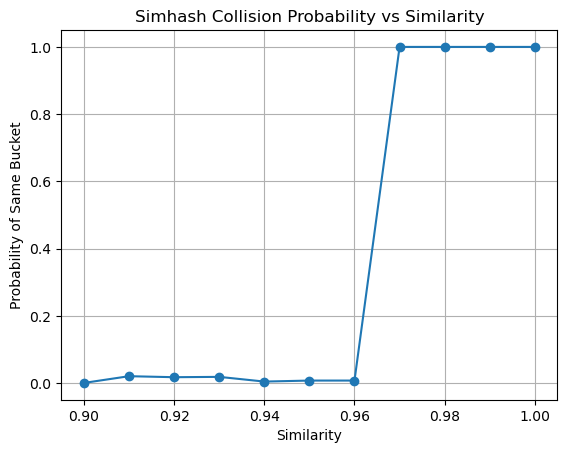

Length: 64
[0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99 1.  ]
[0.002 0.004 0.003 0.007 0.014 0.006 0.025 0.054 0.049 1.    1.   ]


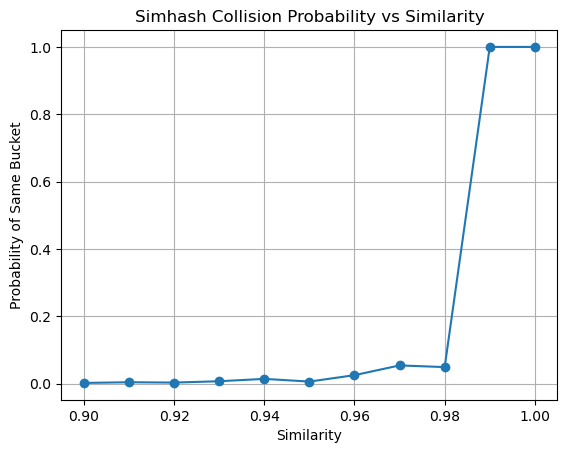

Length: 128
[0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99 1.  ]
[0.006 0.02  0.011 0.037 0.023 0.032 0.037 0.095 0.133 0.216 1.   ]


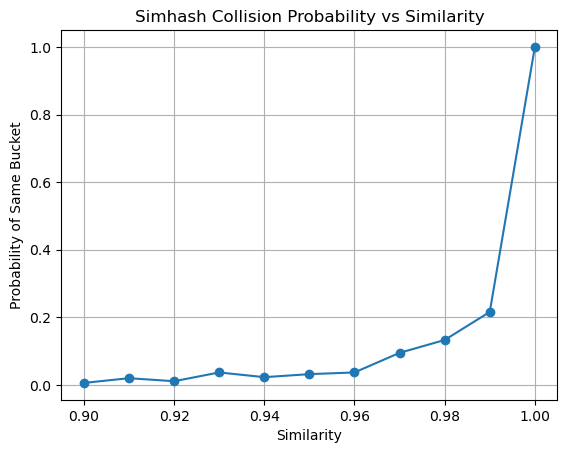

Length: 256
[0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99 1.  ]
[0.027 0.04  0.045 0.061 0.063 0.09  0.112 0.156 0.179 0.374 1.   ]


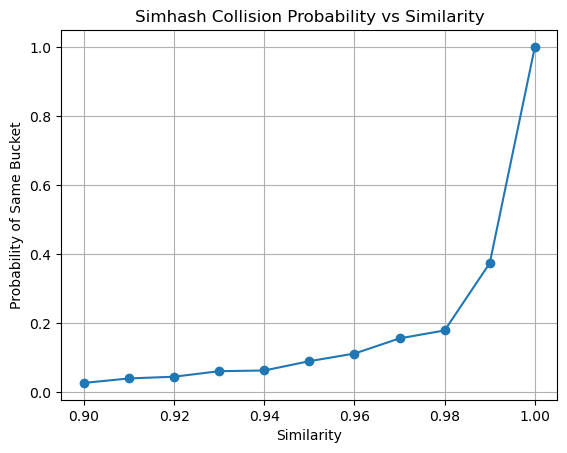

Length: 512
[0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99 1.  ]
[0.067 0.069 0.092 0.099 0.107 0.115 0.154 0.214 0.273 0.391 1.   ]


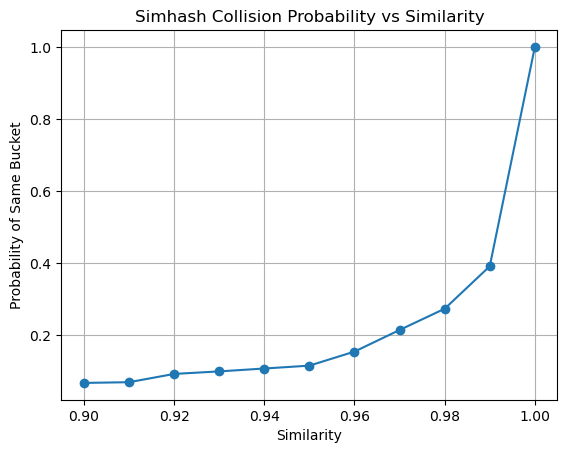

Length: 1024
[0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99 1.  ]
[0.088 0.08  0.101 0.123 0.107 0.184 0.181 0.242 0.301 0.423 1.   ]


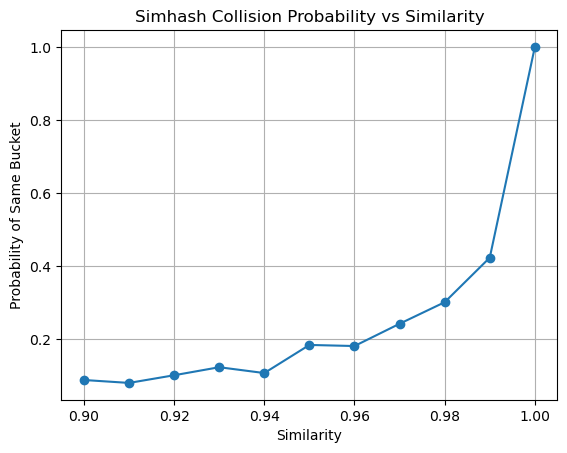

Length: 2048
[0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99 1.  ]
[0.062 0.1   0.11  0.093 0.152 0.16  0.175 0.229 0.302 0.425 1.   ]


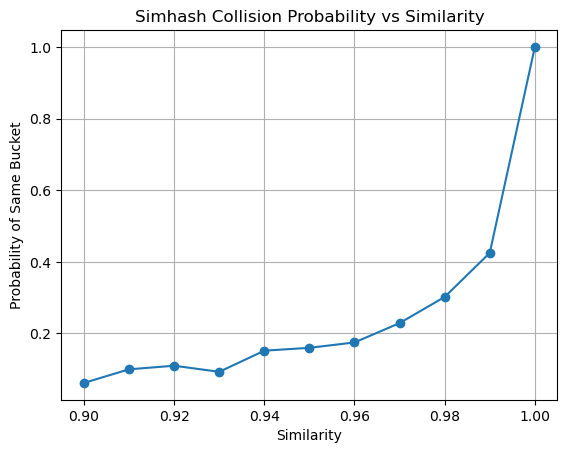

Length: 4096
[0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99 1.  ]
[0.081 0.084 0.091 0.127 0.15  0.147 0.183 0.219 0.293 0.426 1.   ]


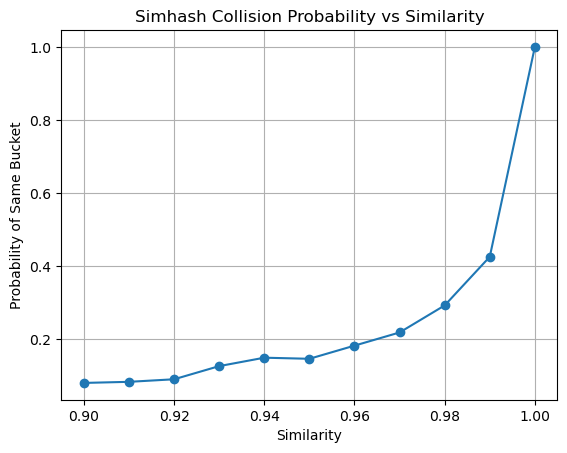

In [96]:
length_array = [32, 64, 128, 256, 512, 1024, 2048, 4096]

similarity_arr = np.linspace(0.90, 1.0, num=11)

num_samples = 1000
num_hashes = 5

for length in length_array:
	print(f"Length: {length}")
	compute_simhash_collision_rate(length, num_samples, similarity_arr)


array([0.95, 0.96, 0.97, 0.98, 0.99, 1.  , 1.01])

In [69]:
similarity_arr_1 = np.linspace(0.90, 1.0, num=11)  # 11 points from 0.90 to 1.0
similarity_arr_2 = np.linspace(0.95, 1.0, num=6)   # 6 points from 0.95 to 1.0

similarity_arr_1

array([0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.  ])

In [ ]:

x_axis = np.arange(0.95, 1.01, step=0.005)

arr_counts = np.zeros(len(x_axis), dtype=np.float32)
# print(arr_counts)


ValueError: Sample larger than population or is negative

In [26]:
generated_pair = generate_bitvector_pair(64, 5)
vec1 = list(generated_pair[0])
vec2 = list(generated_pair[1])
print("Vector 1:", bitvector_to_string(vec1))
print("Vector 2:", bitvector_to_string(vec2))




Vector 1: 0100011111010110010101110001000110001010100010010011001101000111
Vector 2: 0100011111010110010101110111000110001000100000010011101101000111


In [ ]:

hash1 = Simhash(bitvector_to_string(vec1))
hash2 = Simhash(bitvector_to_string(vec2))

print(hash1.value)
print(hash2.value)

print(hash1.batch_size)
print(hash2.batch_size)



# Calculate distance (Hamming distance)
distance = hash1.distance(hash2)
print(f"Hamming distance: {distance}")
print(f"Hash1: {hash1.value:032b}")
print(f"Hash2: {hash2.value:032b}")



15949582175238305171
10797604936865789329
200
200
15949582175238305171
Hamming distance: 9
Hash1: 1101110101011000010011000111101111011110111110110011010110010011
Hash2: 1001010111011000110011000111101101011110111000111011010110010001


In [66]:
print(generate_bitvector_pair(length=16, hamming_distance=3))
print(generate_bitvector_pair(length=16, hamming_distance=3))
print(generate_bitvector_pair(length=16, hamming_distance=3))
print(generate_bitvector_pair(length=16, hamming_distance=3))

(array([0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0], dtype=uint8), array([0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0], dtype=uint8))
(array([1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0], dtype=uint8), array([1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0], dtype=uint8))
(array([1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1], dtype=uint8), array([1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1], dtype=uint8))
(array([1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0], dtype=uint8), array([1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0], dtype=uint8))


In [71]:
list(generate_bitvector_pair(length=64, hamming_distance=5)[0])

[1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1]

In [77]:
count_1 = 0
for i in range(1000000):
	count_1 = count_1 + list(generate_bitvector_pair(length=64, hamming_distance=5)[0])[0]

print(count_1/1000000)


# print(list(generate_bitvector_pair(length=64, hamming_distance=5)[0])[0])
# print(list(generate_bitvector_pair(length=64, hamming_distance=5)[0])[0])
# print(list(generate_bitvector_pair(length=64, hamming_distance=5)[0])[0])
# print(list(generate_bitvector_pair(length=64, hamming_distance=5)[0])[0])
# print(list(generate_bitvector_pair(length=64, hamming_distance=5)[0])[0])
# print(list(generate_bitvector_pair(length=64, hamming_distance=5)[0])[0])
# print(list(generate_bitvector_pair(length=64, hamming_distance=5)[0])[0])
# print(list(generate_bitvector_pair(length=64, hamming_distance=5)[0])[0])
# print(list(generate_bitvector_pair(length=64, hamming_distance=5)[0])[0])
# print(list(generate_bitvector_pair(length=64, hamming_distance=5)[0])[0])

0.500964


In [22]:
def generate_bitvector_pair(length=64, hamming_distance=5):
    """Generate two bitvectors with specified Hamming distance"""
    # Generate first bitvector randomly
    vec1 = np.random.randint(0, 2, length, dtype=np.uint8)
    
    # Create second vector by copying first
    vec2 = vec1.copy()
    
    # Flip exactly 'hamming_distance' bits to create desired distance
    flip_positions = random.sample(range(length), hamming_distance)
    for pos in flip_positions:
        vec2[pos] = 1 - vec2[pos]  # Flip bit
    
    return vec1, vec2

In [23]:
def bitvector_to_int(bitvector):
    """Convert bitvector to integer for SimHash input"""
    return int(''.join(map(str, bitvector)), 2)

def simple_simhash(value, hash_bits=32):
    """Simple SimHash implementation for integers"""
    # Use the integer directly as features
    binary_str = format(value, f'0{hash_bits}b')
    
    # SimHash vector
    v = [0] * hash_bits
    
    # For each bit position, treat as a feature
    for i, bit in enumerate(binary_str):
        weight = 1  # You can adjust weights
        if bit == '1':
            v[i] += weight
        else:
            v[i] -= weight
    
    # Generate final hash
    hash_val = 0
    for i in range(hash_bits):
        if v[i] > 0:
            hash_val |= (1 << i)
    
    return hash_val

In [28]:
def hamming_distance(a, b):
    """Calculate Hamming distance between two integers"""
    return bin(a ^ b).count('1')

def test_simhash_collision_rate():
    """Test collision rates for different Hamming distances"""
    results = defaultdict(list)
    hash_bits = 200
    vector_length = 200
    trials_per_distance = 1000
    
    # Test different Hamming distances
    for target_distance in range(0, vector_length + 1, 5):
        collisions = 0
        
        for trial in range(trials_per_distance):
            # Generate bitvector pair
            vec1, vec2 = generate_bitvector_pair(vector_length, target_distance)
            
            # Convert to integers
            int1 = bitvector_to_int(vec1)
            int2 = bitvector_to_int(vec2)
            
            # Compute SimHash
            hash1 = simple_simhash(int1, hash_bits)
            hash2 = simple_simhash(int2, hash_bits)
            
            # Check for collision (same hash)
            if hash1 == hash2:
                collisions += 1
        
        collision_rate = collisions / trials_per_distance
        results[target_distance].append(collision_rate)
        print(f"Hamming Distance {target_distance:2d}: Collision Rate = {collision_rate:.4f}")
    
    return results

# Run the test
results = test_simhash_collision_rate()


Hamming Distance  0: Collision Rate = 1.0000
Hamming Distance  5: Collision Rate = 0.0000
Hamming Distance 10: Collision Rate = 0.0000
Hamming Distance 15: Collision Rate = 0.0000
Hamming Distance 20: Collision Rate = 0.0000
Hamming Distance 25: Collision Rate = 0.0000
Hamming Distance 30: Collision Rate = 0.0000
Hamming Distance 35: Collision Rate = 0.0000
Hamming Distance 40: Collision Rate = 0.0000
Hamming Distance 45: Collision Rate = 0.0000
Hamming Distance 50: Collision Rate = 0.0000
Hamming Distance 55: Collision Rate = 0.0000
Hamming Distance 60: Collision Rate = 0.0000
Hamming Distance 65: Collision Rate = 0.0000
Hamming Distance 70: Collision Rate = 0.0000
Hamming Distance 75: Collision Rate = 0.0000
Hamming Distance 80: Collision Rate = 0.0000
Hamming Distance 85: Collision Rate = 0.0000
Hamming Distance 90: Collision Rate = 0.0000
Hamming Distance 95: Collision Rate = 0.0000
Hamming Distance 100: Collision Rate = 0.0000
Hamming Distance 105: Collision Rate = 0.0000
Hamming 

In [63]:
from simhash import Simhash

# Create SimHash objects
text1 = "It is easy to understand why SimHash provides similar fingerprints for similar sets. For large sets, adding or removing a few elements hardly changes the majority ratios, and most bits remain the same. Identical sets obviously lead to identical fingerprints corresponding to 100% coinciding bits. In contrast, for disjoint sets that have no common elements, the bits of both fingerprints are completely independent. However, 50% of all bits can be expected to coincide by chance. The collision probability for a single bit is roughly a function of the cosine similarity with a value range between 50% and 100%. This in turn allows estimating the similarity based on the fraction of identical bits, with the estimation error scaling inversely with the square root of the fingerprint length."

text2 = "It is easy tao unsderstand why SimHash provides similar finagerprintss for similar sets. For large sets, adding or removing a few elements hardly changes the majority ratios, and most bits remain the same. Identical sets obviously lead to identical fingerprints corresponding to 100% coinciding bits. In contrast, for disjoint sets that have no common elements, the bits of both fingerprints are completely independent. However, 50% of all bits can be expected to coincide by chance. The collision probaability for a single biit is roughly a faunction of the cosine similarity with a value range between 50% and 100%. This in turn allows estimating the similarity based osn the fraction of identical bits, with the estimation error scaling inversely with the square rooat of the fingerprint length."

hash1 = Simhash(text1)
hash2 = Simhash(text2)

# Calculate distance (Hamming distance)
distance = hash1.distance(hash2)
print(f"Hamming distance: {distance}")
print(f"Hash1: {hash1.value:032b}")
print(f"Hash2: {hash2.value:032b}")

# Check similarity (distance < threshold)
# print(f"Similar: {distance < 3}")

Hamming distance: 3
Hash1: 1011101101001101101101100100001010110101001111101001010011010101
Hash2: 1011101101001101101100100100001011100101001111101001010011010101


In [64]:
len("1011101101001101101101100100001010110101001111101001010011010101")

64